# CRIAR E TREINAR A REDE NEURAL - USAR GPU

In [ ]:
# Link do Colab com o Drive
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf  # Criar a rede neural
from tensorflow import keras
from keras import callbacks, layers, regularizers
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt  # Visualizar imagens
import numpy as np  # Manipulação de arrays
import os
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import cv2
import kagglehub
import numpy as np

# Importação necessária para o modelo pré-treinado
from tensorflow.keras.applications import EfficientNetB0

# 1. Download e definição do caminho
path = kagglehub.dataset_download("mohammadhossein77/brain-tumors-dataset")
print("Caminho original do KaggleHub:", path)

# 2. Coleta Inteligente de Imagens e Rótulos
image_paths = []
labels_raw = []

# Formatos de imagem aceitos
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

# Percorre todas as pastas e subpastas
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(valid_extensions):
            img_path = os.path.join(root, file)
            # A "classe" será o nome da pasta onde a imagem está
            label_name = os.path.basename(root)

            image_paths.append(img_path)
            labels_raw.append(label_name)

# 3. Mapeamento de Classes para Números
class_names_list = sorted(list(set(labels_raw)))
num_classes = len(class_names_list)
class_to_label = {name: i for i, name in enumerate(class_names_list)}

# Converter os nomes das classes para os índices numéricos
labels = np.array([class_to_label[name] for name in labels_raw])
image_paths = np.array(image_paths)

print(f"\nTotal de imagens encontradas: {len(image_paths)}")
print(f"Classes identificadas: {class_names_list}")
for name, idx in class_to_label.items():
    count = list(labels_raw).count(name)
    print(f" - {name}: {count} imagens")

Mounted at /content/drive
Using Colab cache for faster access to the 'brain-tumors-dataset' dataset.
Caminho original do KaggleHub: /kaggle/input/brain-tumors-dataset

Total de imagens encontradas: 21672
Classes identificadas: ['Normal', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
 - Normal: 3066 imagens
 - glioma_tumor: 6307 imagens
 - meningioma_tumor: 6391 imagens
 - pituitary_tumor: 5908 imagens


Using Colab cache for faster access to the 'brain-tumors-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumors-dataset
Total de imagens: 21672
Classes: ['Normal', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- FASE 1: Treinamento com Base Congelada (Transfer Learning) ---
Pressione Stop/Ctrl+C para interromper a qualquer momento.
Epoch 1/50
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6259 - loss: 1.0667 - precision: 0.6520 - recall: 0.5885
Epoch 1: val_loss improved from inf to 0.45876, saving model to /content/drive/MyDrive/Projeto/modelos_salvos/TLSeg_128_6.keras
1084/1084 ━━━━━━━━━━━━━━━━━━━━ 179s 138ms/step - accuracy: 0.6260 - loss: 1.0665 - precision: 0.6520 - recall: 0.5886 - val_accuracy: 0.8251 - val_loss: 0.4588 - val_precision: 0.8683 - val_recall: 0.7850 - learning_rate: 0.0010
Epoch 2/50
1082/1084 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7613 - loss: 0.6193 - precision: 0.793

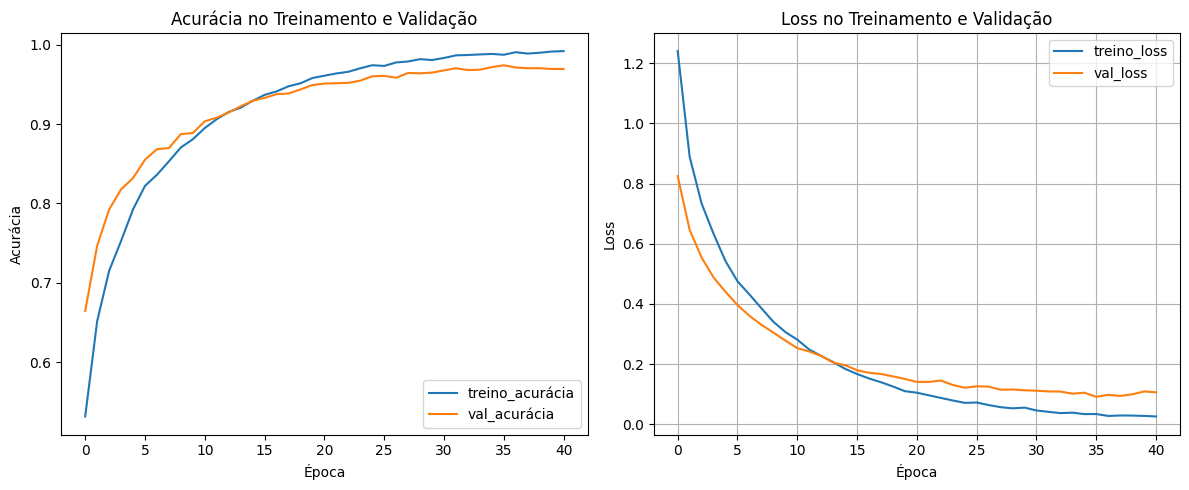


Avaliação do modelo final no conjunto de teste:
136/136 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - accuracy: 0.9686 - loss: 0.1261 - precision: 0.9719 - recall: 0.9668
Loss no teste: 0.1755
Acurácia no teste: 0.9654
Precisão no teste: 0.9671
Recall no teste: 0.9626
136/136 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step
F1-score no teste: 0.9653
Pronto para gerar matriz de confusão


In [ ]:
# --- DOWNLOAD E CONFIGURAÇÃO DO DATASET ---
# Baixa a versão mais recente do dataset do Kaggle
path = kagglehub.dataset_download("mohammadhossein77/brain-tumors-dataset")
print("Path to dataset files:", path)

IMAGE_SIZE = (128, 128)
AUTOTUNE = tf.data.AUTOTUNE

# --- FUNÇÃO DE SEGMENTAÇÃO (OpenCV) ---
def segment_image_cv(image_tensor):
    img = image_tensor.numpy().astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Se a imagem vier com shape (1, 128, 128, 3), remove o 1
    if len(img.shape) == 4:
        img = np.squeeze(img, axis=0)

    # Conversão para tons de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # Otsu Thresholding
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Aplica a máscara
    segmented = cv2.bitwise_and(img, img, mask=thresh)

    return segmented.astype(np.float32)

# --- COLETA RECURSIVA DE IMAGENS E RÓTULOS ---
image_paths = []
labels_raw = []
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

# Caminha por todas as subpastas do Kaggle
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(valid_extensions):
            img_path = os.path.join(root, file)
            label_name = os.path.basename(root)
            image_paths.append(img_path)
            labels_raw.append(label_name)

# Mapeamento de classes
class_names_list = sorted(list(set(labels_raw)))
num_classes = len(class_names_list)
class_to_label = {name: i for i, name in enumerate(class_names_list)}
labels = np.array([class_to_label[name] for name in labels_raw])
image_paths = np.array(image_paths)

# --- DIVISÃO DOS DADOS ---
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, random_state=42, stratify=test_labels
)

print(f"Total de imagens: {len(image_paths)}")
print(f"Classes: {class_names_list}")

# --- DATASET E AUGMENTATION ---
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.02)
], name="data_augmentation")

def create_tf_dataset(image_paths, labels, num_classes, batch_size, shuffle=False, augment=False):
    def load_image(image_path, label):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMAGE_SIZE)

        # Aplicação da Segmentação via py_function
        [img,] = tf.py_function(segment_image_cv, [img], [tf.float32])
        img.set_shape((IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

        label = tf.one_hot(label, num_classes)
        return img, label

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)

    if augment:
         dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    dataset = dataset.batch(batch_size)
    dataset = dataset.cache().prefetch(buffer_size=AUTOTUNE)
    return dataset

train_dataset = create_tf_dataset(train_paths, train_labels, num_classes, batch_size=16, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_paths, val_labels, num_classes, batch_size=16)
test_dataset = create_tf_dataset(test_paths, test_labels, num_classes, batch_size=16)

# --- MODELO, TREINO E AVALIAÇÃO ---
def create_model(num_classes):
    # 1. Carrega a base pré-treinada (sem o topo/classificador)
    # include_top=False remove a camada final de classificação (que é para 1000 classes)
    # weights='imagenet' carrega os pesos aprendidos
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    )

    # 2. Congelar a Base
    # Impede que os pesos do modelo sejam atualizados na primeira fase do treino
    base_model.trainable = False

    # 3. Construir o Modelo Completo
    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

    # A EfficientNet espera valores 0-255, então NÃO usa Rescaling(1./255)
    # Se fosse VGG16 ou ResNet, precisaria de pré-processamento específico.

    # O parâmetro training=False é crucial para manter a BatchNormalization em modo de inferência
    x = base_model(inputs, training=False)

    # Reconstruindo o cabeçalho (Head) de classificação
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x) # Ajuda a estabilizar o treino
    x = layers.Dropout(0.4)(x)         # Reduz overfitting

    # Camada densa opcional para aprender características mais específicas antes da saída
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.35)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="EfficientNet_TransferLearning")

    # 4. Compilar
    model.compile(
        loss="categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=["accuracy", tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )

    return model

model = create_model(num_classes)

# Early Stopping e Learning Rate para o treinamento
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001
)

# Callback para salvar o melhor modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Projeto/modelos_salvos/TLSeg_128_6.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# -------------------------------------------------------------------------------------------
# ESSA PARTE É CASO PARE O TREINAMENTO NO MEIO
def finalizar_e_plotar(model, history, test_dataset):
    print("\nIniciando plotagem e avaliação...")

    # Parte 1: Gráficos de Treino
    if history is not None and hasattr(history, 'history'):
        # Plotagem dos resultados do treinamento
        plt.figure(figsize=(12, 5))

        # Plotar Acurácia
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='treino_acurácia')
        plt.plot(history.history['val_accuracy'], label='val_acurácia')
        plt.xlabel('Época')
        plt.ylabel('Acurácia')
        plt.title('Acurácia no Treinamento e Validação')
        plt.legend(loc='lower right')

        # Plotar Loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='treino_loss')
        plt.plot(history.history['val_loss'], label='val_loss')
        plt.xlabel('Época')
        plt.ylabel('Loss')
        plt.title('Loss no Treinamento e Validação')
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    else:
        print("Histórico de treinamento incompleto ou inexistente. Pulando gráficos de evolução.")

    # Parte 2: Avaliação do Modelo (Funciona mesmo se parar no meio, pois usa o estado atual do model)
    print("\nAvaliação do modelo final no conjunto de teste:")
    try:
        loss, accuracy, precision, recall = model.evaluate(test_dataset)

        print(f"Loss no teste: {loss:.4f}")
        print(f"Acurácia no teste: {accuracy:.4f}")
        print(f"Precisão no teste: {precision:.4f}")
        print(f"Recall no teste: {recall:.4f}")

        # Calcular F1-score
        y_pred_probs = model.predict(test_dataset)
        y_pred = np.argmax(y_pred_probs, axis=1)

        y_true = []
        for images, labels in test_dataset.unbatch():
            y_true.append(np.argmax(labels.numpy()))
        y_true = np.array(y_true)

        f1 = f1_score(y_true, y_pred, average='weighted') # Usar 'weighted' para multiclasse
        print(f"F1-score no teste: {f1:.4f}")

    except Exception as e:
        print(f"Erro ao avaliar o modelo: {e}")

# -------------------------------------------------------------------------------------------
# BLOCO DE TREINAMENTO COM FINE-TUNING
history = None

try:
    print("--- FASE 1: Treinamento com Base Congelada (Transfer Learning) ---")
    print("Pressione Stop/Ctrl+C para interromper a qualquer momento.")

    # 1. Primeiro Treino (O modelo aprende o básico das novas classes)
    history = model.fit(
        train_dataset,
        epochs=50,
        validation_data=val_dataset,
        callbacks=[early_stopping, reduce_lr, model_checkpoint_callback]
    )

    # ---------------- COMEÇO DO FINE TUNING ----------------
    # Este código só roda se a Fase 1 terminar sem erros ou interrupções
    print("\n--- FASE 2: Iniciando Fine-Tuning (Ajuste Fino) ---")

    # A. Descongelar a base (EfficientNet)
    # No modelo funcional criado, a camada [0] é o Input e a [1] é a EfficientNet
    model.layers[1].trainable = True

    # B. Recompilar com taxa de aprendizado MUITO BAIXA (Crucial)
    # Usa 1e-5 (0.00001) para ajustar os pesos suavemente sem destruir o conhecimento
    model.compile(
        loss="categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        metrics=["accuracy", tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )

    # C. Treinar novamente (Fase de Refinamento)
    # Adiciona mais épocas ao total (ex: 50 iniciais + 20 de refino)
    total_epochs = 50 + 20

    # Pega a última época do treino anterior para continuar a contagem correta
    initial_epoch = history.epoch[-1] + 1

    history_fine = model.fit(
        train_dataset,
        epochs=total_epochs,
        initial_epoch=initial_epoch, # Começa da época 51
        validation_data=val_dataset,
        callbacks=[early_stopping, reduce_lr, model_checkpoint_callback]
    )

    # D. Atualiza o histórico para o gráfico final mostrar o resultado do refino
    history = history_fine
# ---------------- FIM DO FINE TUNING ----------------

except KeyboardInterrupt:
    print("\n\nTreinamento interrompido MANUALMENTE pelo usuário!")
    print("Gerando gráficos com o estado atual do modelo...")

finally:
    # 1. Primeiro roda a sua função de avaliação normal
    finalizar_e_plotar(model, history, test_dataset)

    # Salva as listas de teste para não perder a referência das imagens
    np.save('/content/drive/MyDrive/Projeto/test_paths.npy', test_paths)
    np.save('/content/drive/MyDrive/Projeto/test_labels.npy', test_labels)

    print("Pronto para gerar matriz de confusão")

# GERAR MATRIZ DE CONFUSÃO - USAR CPU

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'brain-tumors-dataset' dataset.
Kaggle dataset re-downloaded to: /kaggle/input/brain-tumors-dataset
68/68 ━━━━━━━━━━━━━━━━━━━━ 493s 7s/step
Matriz de confusão salva em /content/drive/MyDrive/Projeto/resultados/matriz_confusao.png


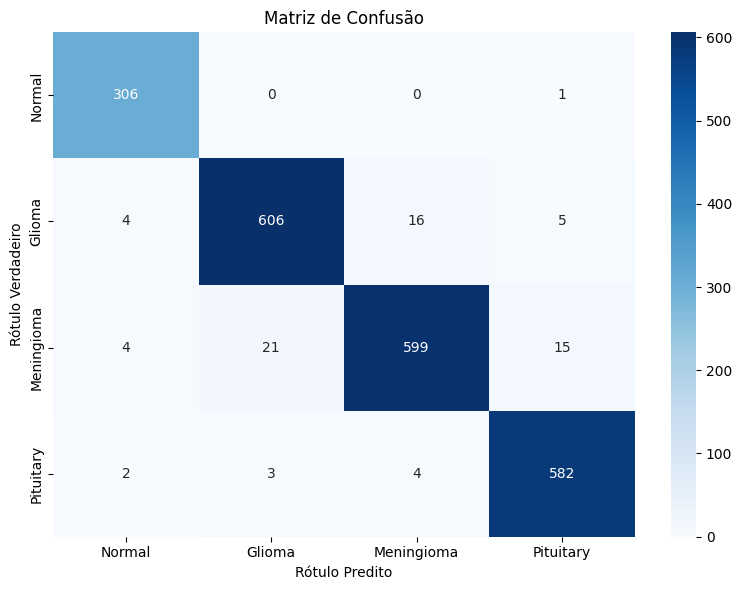

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import kagglehub
import os

# PASSOS 1 A 4 SÃO NECESSÁRIOS QUANDO SE TROCA DE GPU PARA CPU
# 1. Re-download do dataset
path = kagglehub.dataset_download("mohammadhossein77/brain-tumors-dataset")
print("Kaggle dataset re-downloaded to:", path)

# 2. Carregar dados do Drive
test_paths = np.load('/content/drive/MyDrive/Projeto/PARA UPLOAD/test_paths.npy')
test_labels = np.load('/content/drive/MyDrive/Projeto/PARA UPLOAD/test_labels.npy')

# 3. Carregar o modelo
model = keras.models.load_model('/content/drive/MyDrive/Projeto/PARA UPLOAD/TLSeg_128_6.keras')

# 4. Re-definir configurações básicas
IMAGE_SIZE = (128, 128)

def segment_image_cv(image_tensor):
    img = image_tensor.numpy().astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Se a imagem vier com shape (1, 128, 128, 3), remove o 1
    if len(img.shape) == 4:
        img = np.squeeze(img, axis=0)

    # Conversão para tons de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # Otsu Thresholding
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Aplica a máscara
    segmented = cv2.bitwise_and(img, img, mask=thresh)

    return segmented.astype(np.float32)

def create_tf_dataset(image_paths, labels, batch_size=32):
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMAGE_SIZE)
        [img,] = tf.py_function(segment_image_cv, [img], [tf.float32])
        img.set_shape((IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
        # O número de classes é 4
        return img, tf.one_hot(label, 4)
    return tf.data.Dataset.from_tensor_slices((image_paths, labels)).map(load_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Gerar matriz de confusão
test_ds = create_tf_dataset(test_paths, test_labels)
y_pred = np.argmax(model.predict(test_ds), axis=1)

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Glioma', 'Meningioma', 'Pituitary'],
            yticklabels=['Normal', 'Glioma', 'Meningioma', 'Pituitary'])
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Predito')
plt.tight_layout()

# Salvar a matriz de confusão no Google Drive para garantir que seja visualizada
output_dir = '/content/drive/MyDrive/Projeto/resultados'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, 'matriz_confusao.png'))
print(f"Matriz de confusão salva em {os.path.join(output_dir, 'matriz_confusao.png')}")

plt.show()